# XGBOOST

In [1]:
#path config set
import sys
from pathlib import Path

project_root = Path.cwd().parent
for folder in ["functions", "other"]:
    p = str(project_root / folder)
    if p not in sys.path:
        sys.path.append(p)

In [2]:
# import potrebnych kniznic a konfiguracia notebooku
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

    #import importlib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

import shap

from cred import DATA_PATH_CRED
from functions_xgboost import make_features, rolling_forecast_xgboost, trace_path_for_observation, extract_tree_structure, hyperparameters_tuning
from functions_general import forecast_plot

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

plt.rcParams.update({
    "figure.figsize": (13, 4),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})


print("Importy uspesne.")


C:\Users\adamv\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Importy uspesne.


In [3]:
# konfiguracia a stiahnutie dat
main_dir = Path(DATA_PATH_CRED)
data_mod = "data_mod.csv"
pp_orig = "data.xlsx"
DATA_PATH_DATA_MOD  = main_dir / data_mod
DATA_PATH_DATA = main_dir / pp_orig
SHEET_NAME_PP = "pp"
SHEET_NAME_EXOG = "exog"
TEST_SIZE = 24
RANDOM_STATE = 24
TARGET_VAR = "pp_sa_ca_jd"

df_raw = pd.read_csv(DATA_PATH_DATA_MOD)
df_raw["datum"] = pd.to_datetime(df_raw["datum"])
df_raw = df_raw.set_index("datum").sort_index()
df_raw = df_raw.asfreq("MS")
df = df_raw.copy()

df_pp = pd.read_excel(DATA_PATH_DATA,SHEET_NAME_PP)
df_pp = df_pp.set_index("datum").sort_index()
df_pp = df_pp.asfreq("MS")


In [4]:
#definovanie features, train/test vzorka
exog_cols = df.drop(columns=[TARGET_VAR,"pp_nonsa","pp_sa_orig"])
features = make_features(
    data=df,
    target=TARGET_VAR,
    exog_cols=exog_cols,
    target_lags=(1, 2, 3, 6, 12),
    exog_lags=(1,)
)

X = features.drop(columns = [TARGET_VAR, "pp_sa_ca_jd_lag1"])
y = features[TARGET_VAR]

X_train, X_test = X.iloc[:-TEST_SIZE], X.iloc[-TEST_SIZE:]
y_train, y_test = y.iloc[:-TEST_SIZE], y.iloc[-TEST_SIZE:]

print(f"Trenovacia mnozina: {y_train.index.min().date()} az {y_train.index.max().date()} ({len(y_train)} obs.)")
print(f"Testovacia mnozina: {y_test.index.min().date()} az {y_test.index.max().date()} ({len(y_test)} obs.)")


Trenovacia mnozina: 2001-02-01 az 2023-12-01 (275 obs.)
Testovacia mnozina: 2024-01-01 az 2025-12-01 (24 obs.)


In [5]:
grid_search, best_params = hyperparameters_tuning(X_train, y_train)

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Najlepsie parametre z Random Search: {'subsample': 0.6, 'reg_lambda': 1, 'reg_alpha': 0.01, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.005, 'gamma': 1, 'colsample_bytree': 0.7}
Fitting 5 folds for each of 81 candidates, totalling 405 fits
Finalne parametre po Grid Search: {'colsample_bytree': 0.7, 'gamma': 0, 'learning_rate': 0.0025, 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 300, 'reg_alpha': 0.01, 'reg_lambda': 1, 'subsample': 0.6}


In [15]:
init_train_size = len(y) - TEST_SIZE
xgb_res = rolling_forecast_xgboost(
    X=X,
    y_diff= y,
    level_series=df_pp[TARGET_VAR],
    initial_train_size=init_train_size,
    xgb_params=best_params
)

RMSE (diferencia):      2.5036
RMSE (level, onestep):  2.5036
WMAPE (level):          1.91%
ME (level):             -0.4431
Refity:                 24 / 24


In [16]:
results_xgboost = xgb_res["results"]
results_xgboost.to_parquet("data/xgb_res")
diagnostics = xgb_res["diagnostics"]
fi = diagnostics['feature_importance']
hp = diagnostics['hyperparams']
refit_diag = xgb_res["refit_diagnostics"]
summary_xgb = xgb_res["summary"]
summary_xgb = pd.DataFrame([summary_xgb])
summary_xgb.to_parquet("data/xgb_sum")

In [71]:
results_xgboost.columns

Index(['actual_diff', 'predicted_diff', 'actual_level', 'predicted_level',
       'abs_error_diff', 'sq_error_diff', 'abs_error_level', 'sq_error_level',
       'pct_error_level', 'error_diff', 'error_level', 'refit',
       'model_refit_date', 'rolling_rmse_level', 'rolling_mape_level',
       'window6_rmse_level'],
      dtype='str')

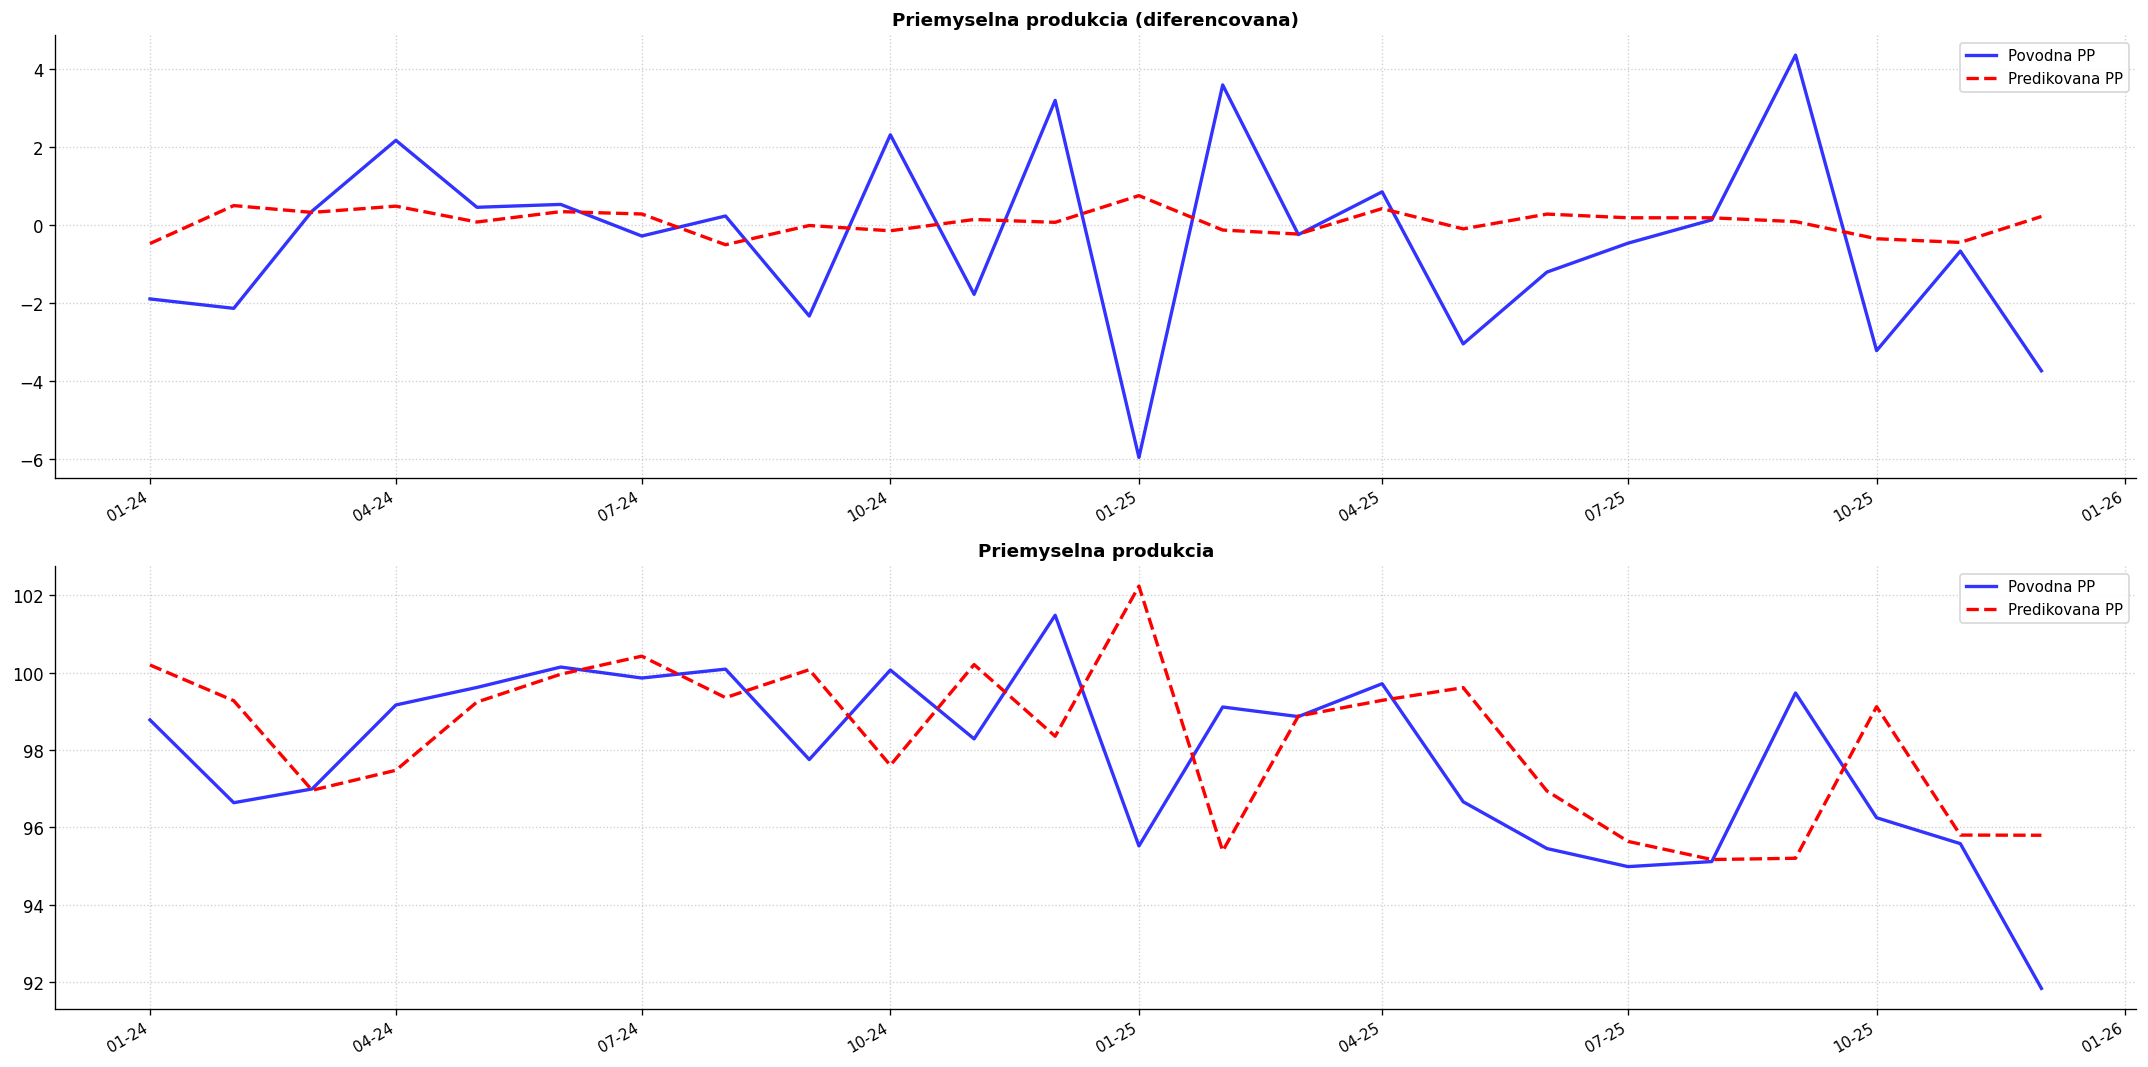

In [69]:
Y_axis = [results_xgboost["actual_diff"], results_xgboost["predicted_diff"], results_xgboost["actual_level"], results_xgboost["predicted_level"]]
X_axis = [results_xgboost.index] * len(Y_axis)
labels = ["Povodna PP", "Predikovana PP"] * len(Y_axis)
titles = ["Priemyselna produkcia (diferencovana)", "Priemyselna produkcia"]
colors = ["#0000FF", "#FF0000"] * len(Y_axis)
linestyles = ["-","--"] * len(Y_axis)
linewidths = [] * len(Y_axis)
alphas = [0.8,1] * len(Y_axis)
fig_size = [18,9]
num_rows = 2
num_cols = 1

_ = forecast_plot(X_axis,Y_axis,titles, labels, colors, linestyles, linewidths, alphas,fig_size, num_rows, num_cols)

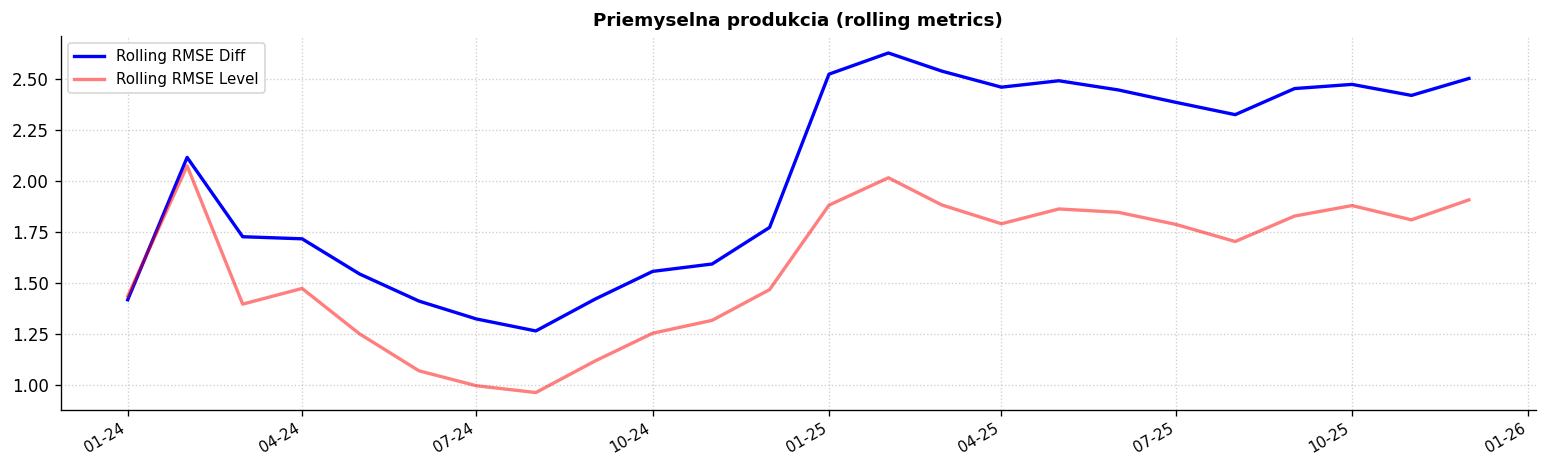

In [73]:
Y_axis = [results_xgboost["rolling_rmse_level"], results_xgboost["rolling_mape_level"]]
X_axis = [results_xgboost.index] * len(Y_axis)
labels = ["Rolling RMSE Diff", "Rolling RMSE Level", "Rolling MAPE Level"] * len(Y_axis)
titles = ["Priemyselna produkcia (rolling metrics)"]
colors = ["#0000FF", "#FF0000", "#008000"] * len(Y_axis)
linestyles = ["-"] * len(Y_axis)
linewidths = [] * len(Y_axis)
alphas = [1, 0.5, 1] * len(Y_axis)
fig_size = [13,4]
num_rows = 1
num_cols = 1
curves_per_plot = 3

_ = forecast_plot(X_axis,Y_axis,titles, labels, colors, linestyles, linewidths, alphas,fig_size, num_rows, num_cols, curves_per_plot)

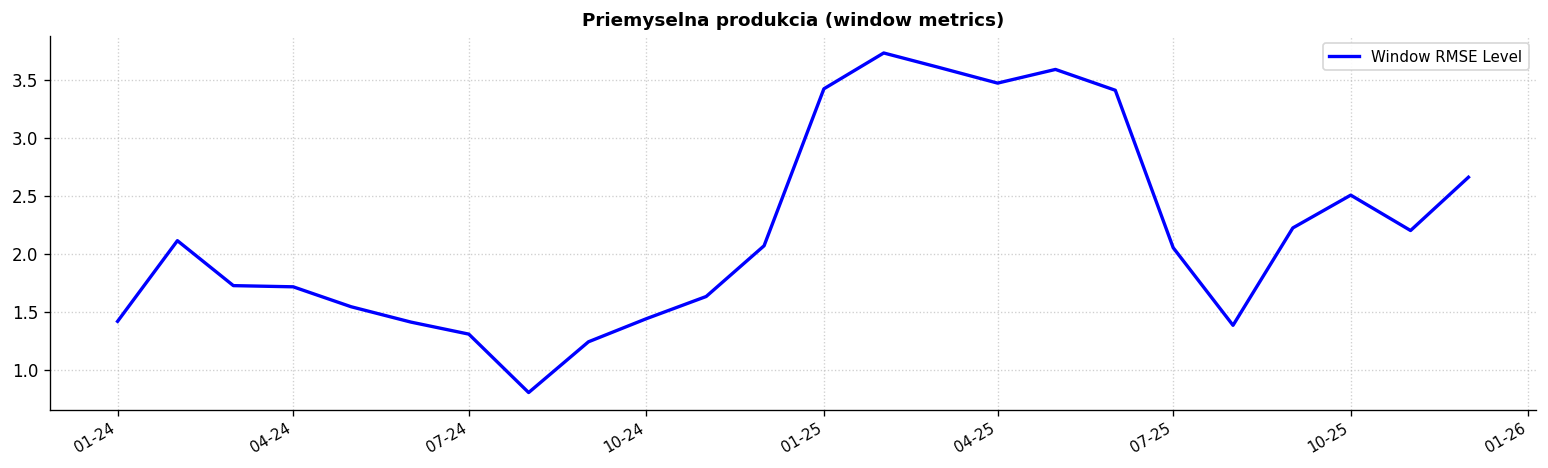

In [75]:
Y_axis = [results_xgboost["window6_rmse_level"]] #results_xgboost["window6_mape_level"], results_xgboost["window6_me_level"]
X_axis = [results_xgboost.index] * len(Y_axis)
labels = ["Window RMSE Level"] * len(Y_axis) #, "Window MAPE Level", "Window ME Level"
titles = ["Priemyselna produkcia (window metrics)"]
colors = ["#0000FF"] * len(Y_axis) #, "#FF0000", "#008000"
linestyles = ["-"] * len(Y_axis)
linewidths = [] * len(Y_axis)
alphas = [1] * len(Y_axis)
fig_size = [13,4]
num_rows = 1
num_cols = 1
curves_per_plot = 3

_ = forecast_plot(X_axis,Y_axis,titles, labels, colors, linestyles, linewidths, alphas,fig_size, num_rows, num_cols, curves_per_plot)

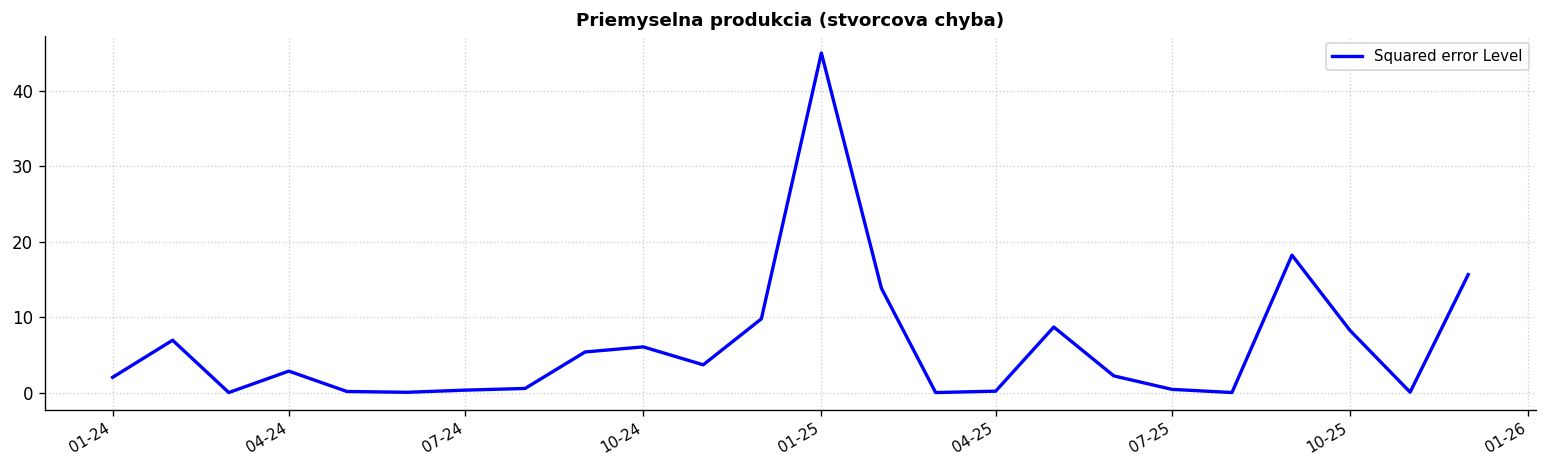

In [76]:
Y_axis = [results_xgboost["sq_error_level"]]
X_axis = [results_xgboost.index] * len(Y_axis)
labels = ["Squared error Level"] * len(Y_axis)
titles = ["Priemyselna produkcia (stvorcova chyba)"]
colors = ["#0000FF"] * len(Y_axis)
linestyles = ["-"] * len(Y_axis)
linewidths = [] * len(Y_axis)
alphas = [1] * len(Y_axis)
fig_size = [13,4]
num_rows = 1
num_cols = 1
curves_per_plot = 3

_ = forecast_plot(X_axis,Y_axis,titles, labels, colors, linestyles, linewidths, alphas,fig_size, num_rows, num_cols, curves_per_plot)

In [79]:
print(xgb_res.keys())

dict_keys(['results', 'models_by_step', 'refit_diagnostics', 'step_diagnostics', 'misaligned_dates', 'summary', 'diagnostics'])


In [80]:
#shap
models_by_step = xgb_res["models_by_step"]
last_date = max(models_by_step.keys())
xgb_model = models_by_step[last_date]

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)
shap_summary = pd.DataFrame(shap_values, columns = X_test.columns, index = X_test.index)
mean_abs_shap = np.abs(shap_summary).mean().sort_values(ascending=False)
mean_abs_shap

expected_industry_production_lag1     0.114868
industry_confidence_sa_lag1           0.055545
pp_sa_ca_jd_lag6                      0.051240
vklady_nefinancne_podniky_lag1        0.050522
trzby_priemysel_sa_lag1               0.050464
oil_price_eur_lag1                    0.041548
infl_cpi_lag1                         0.034545
expected_employment_lag1              0.033649
economic_sentiment_lag1               0.031641
ipcv_priemysel_lag1                   0.030838
pp_sa_ca_jd_lag2                      0.027646
trend                                 0.026723
pp_sa_ca_jd_lag12                     0.025144
cpi_nsa_lag1                          0.024694
oil_europe_eur_lag1                   0.024445
current_total_demand_sa_lag1          0.017376
uvery_celkom_lag1                     0.013603
kurz_usd_eur_lag1                     0.013442
fin_stock_lag1                        0.012810
cdd_lag1                              0.012698
sh_prices_non_sa_lag1                 0.011075
sadzba_3m_eur

In [ ]:
#graf ku shapu
shap.summary_plot(shap_values, X_test)

In [81]:
shap_rows = []

for forecast_date, xgb_model in models_by_step.items():

    X_one = X_test.loc[[forecast_date]].copy()

    explainer = shap.TreeExplainer(xgb_model)
    shap_one = explainer(X_one)

    for feature, value, contribution in zip(X_one.columns, X_one.iloc[0].values, shap_one.values[0]):
        shap_rows.append(
            {
                "forecast_date": forecast_date,
                "feature": feature,
                "feature_value": value,
                "shap_value": contribution,
                "abs_shap_value": abs(contribution),
            }
        )

shap_long = pd.DataFrame(shap_rows)
shap_long


,forecast_date,feature,feature_value,shap_value,abs_shap_value
0,2024-01-01,pp_sa_ca_jd_lag2,-2.366972,-0.057485,0.057485
1,2024-01-01,pp_sa_ca_jd_lag3,2.416140,0.060562,0.060562
2,2024-01-01,pp_sa_ca_jd_lag6,-5.675175,-0.020404,0.020404
3,2024-01-01,pp_sa_ca_jd_lag12,8.032883,-0.033229,0.033229
4,2024-01-01,cpi_nsa_lag1,-0.307200,0.118996,0.118996
...,...,...,...,...,...
835,2025-12-01,oil_europe_eur_lag1,-0.304100,-0.003455,0.003455
836,2025-12-01,crisis_dummy_lag1,0.000000,0.000000,0.000000
837,2025-12-01,month,12.000000,0.003546,0.003546
838,2025-12-01,quarter,4.000000,-0.000246,0.000246


In [82]:
shap_global = (
    shap_long
    .groupby("feature", as_index= False)
    .agg(
        mean_abs_shap = ("abs_shap_value", "mean"),
        mean_shap = ("shap_value", "mean"),
        median_abs_shap=("abs_shap_value", "median"),
    )
    .sort_values("mean_abs_shap", ascending=False)
)

print(shap_global.head(15).to_string(index=False))

                          feature  mean_abs_shap  mean_shap  median_abs_shap
expected_industry_production_lag1       0.122468   0.015822         0.124710
   vklady_nefinancne_podniky_lag1       0.074622  -0.008258         0.051891
          trzby_priemysel_sa_lag1       0.057217   0.000769         0.011935
      industry_confidence_sa_lag1       0.055874   0.006308         0.037678
                 pp_sa_ca_jd_lag6       0.051724   0.000746         0.039799
               oil_price_eur_lag1       0.041609  -0.001390         0.033205
          economic_sentiment_lag1       0.034699   0.000434         0.015936
                            trend       0.034374  -0.034374         0.030804
                         cdd_lag1       0.031541  -0.021952         0.005159
                 pp_sa_ca_jd_lag2       0.030844   0.003953         0.030827
                     cpi_nsa_lag1       0.029414  -0.002193         0.017723
              ipcv_priemysel_lag1       0.024107  -0.007228         0.013746

In [83]:
trees_df = extract_tree_structure(xgb_model)

In [84]:
# iba listove uzly (vahy) jedneho konkretneho stromu
tree_0_leaves = trees_df[(trees_df["Tree"] == 0) & (trees_df["Feature"] == "Leaf")]
print(tree_0_leaves[["Tree", "Node", "Gain", "Cover"]])

    Tree  Node      Gain  Cover
1      0     1 -0.026787    2.0
7      0     7  0.013747    3.0
15     0    15 -0.000769    2.0
16     0    16 -0.006312    2.0
17     0    17 -0.000525    6.0
18     0    18  0.007076   12.0
19     0    19  0.005524    6.0
20     0    20  -0.00101   11.0
21     0    21 -0.008682    6.0
22     0    22 -0.002013   64.0
23     0    23 -0.004806    9.0
24     0    24  0.002799    2.0
25     0    25  0.003291   52.0
26     0    26  0.011567    3.0


In [85]:
#najcastejsie pouzivane premenne na delenie
split_counts = (
    trees_df[trees_df["Feature"] != "Leaf"]
    .groupby("Feature")
    .size()
    .sort_values(ascending=False)
)
print(split_counts)

Feature
pp_sa_ca_jd_lag2                      443
pp_sa_ca_jd_lag3                      197
oil_price_eur_lag1                    192
export_celkovy_sa_lag1                174
trzby_priemysel_sa_lag1               173
expected_industry_production_lag1     172
pp_sa_ca_jd_lag12                     158
vklady_nefinancne_podniky_lag1        152
pp_sa_ca_jd_lag6                      149
infl_cpi_lag1                         122
cpi_nsa_lag1                          108
industry_confidence_sa_lag1           107
oil_europe_eur_lag1                   101
current_total_demand_sa_lag1           93
expected_employment_lag1               89
ipcv_priemysel_lag1                    87
economic_sentiment_lag1                86
sadzba_3m_euribor_lag1                 82
kurz_usd_eur_lag1                      78
uvery_celkom_lag1                      72
cpi_sa_lag1                            67
sh_prices_non_sa_lag1                  67
unem_prod_lag1                         54
trend                     

In [86]:
#priemerny Gain pri deleni podla premennej
avg_gain_by_feature = (
    trees_df[trees_df["Feature"] != "Leaf"]
    .groupby("Feature")["Gain"]
    .mean()
    .sort_values(ascending=False)
)
print(avg_gain_by_feature)

Feature
current_total_demand_sa_lag1          138.445989
oil_europe_usd_lag1                   124.112994
oil_price_eur_lag1                    118.250856
oil_europe_eur_lag1                   101.527495
foreign_demand_sa_lag1                 98.374144
export_celkovy_sa_lag1                 94.326332
expected_industry_production_lag1      93.622348
industry_confidence_sa_lag1            83.340443
trzby_priemysel_sa_lag1                83.168766
infl_cpi_lag1                          65.715013
vklady_nefinancne_podniky_lag1         64.554613
economic_sentiment_lag1                60.698912
pp_sa_ca_jd_lag2                       56.065253
month                                  55.909666
cdd_lag1                               51.501931
finished_goods_inventories_sa_lag1     49.752171
sh_prices_non_sa_lag1                   46.54129
ipcv_priemysel_lag1                    45.447001
cpi_sa_lag1                            44.753089
hdd_lag1                               43.745831
expected_emp

In [88]:
#kompletna struktura jedneho konkretneho stromu
last_tree = trees_df.iloc[-1, 0]
tree_last_full = trace_path_for_observation(trees_df, tree_index=last_tree)
print(tree_last_full)

      Node                         Feature     Split     Yes      No  \
7147     0          export_celkovy_sa_lag1 -667.8832   299-1   299-2   
7148     1                            Leaf      <NA>    <NA>    <NA>   
7149     2     industry_confidence_sa_lag1       0.3   299-3   299-4   
7150     3  vklady_nefinancne_podniky_lag1     877.0   299-5   299-6   
7151     4                  inflation_lag1       0.5   299-7   299-8   
7152     5           sh_prices_non_sa_lag1    1.1218   299-9  299-10   
7153     6  vklady_nefinancne_podniky_lag1    1019.0  299-11  299-12   
7154     7          export_celkovy_sa_lag1  137.5967  299-13  299-14   
7155     8           sh_prices_non_sa_lag1   2.21284  299-15  299-16   
7156     9         trzby_priemysel_sa_lag1  495.8414  299-17  299-18   
7157    10             oil_europe_usd_lag1      -0.6  299-19  299-20   
7158    11                            Leaf      <NA>    <NA>    <NA>   
7159    12                   infl_cpi_lag1   -0.3072  299-21  29

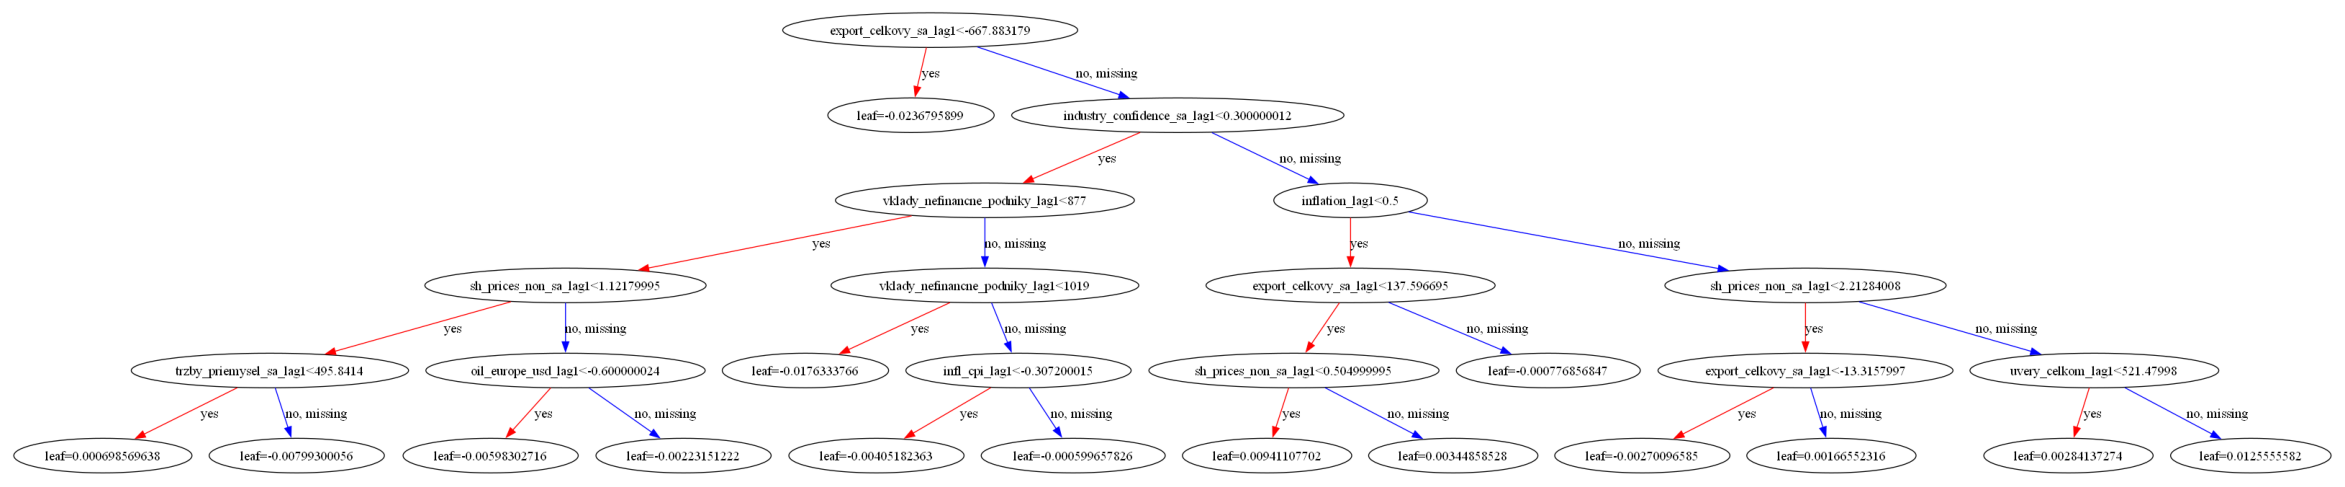

In [89]:
#graficke zobrazenie stromu
from xgboost import plot_tree
import matplotlib.pyplot as plt

plot_tree(xgb_model, num_trees=last_tree)
fig = plt.gcf()
fig.set_size_inches(30, 15)

In [90]:
#Pocet listov a vnutornych uzlov pre kazdy strom
tree_summary = trees_df.groupby("Tree").agg(
    n_nodes=("Node", "count"),
    n_leaves=("Feature", lambda x: (x == "Leaf").sum()),
).reset_index()

# pre binarny strom: n_splits = n_leaves - 1
tree_summary["n_splits"] = tree_summary["n_leaves"] - 1

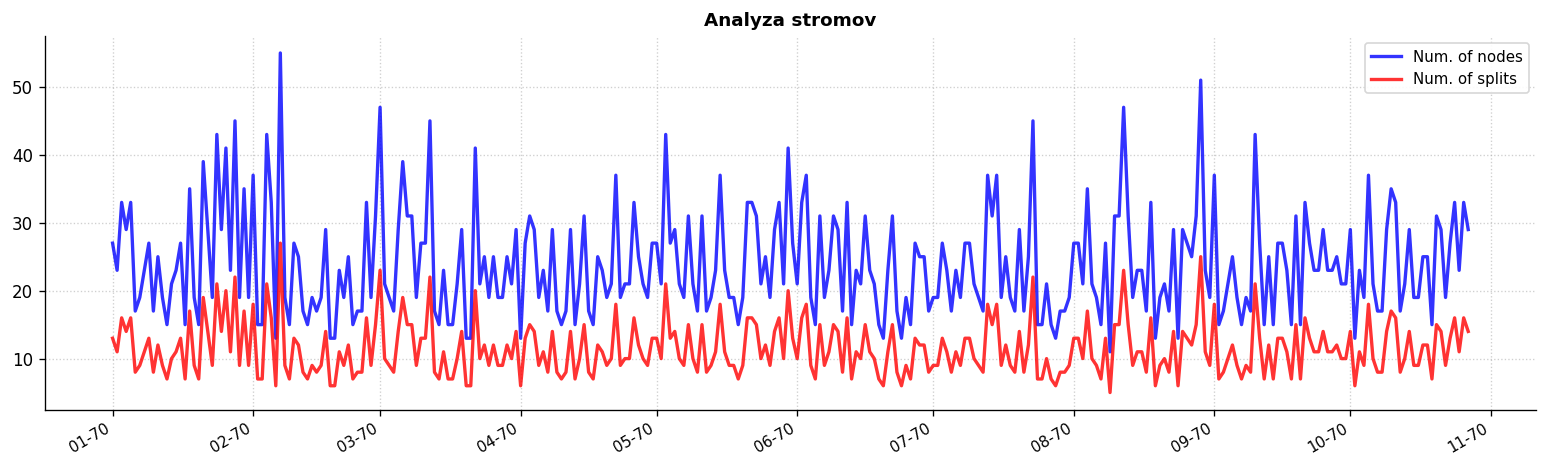

In [91]:
Y_axis = [tree_summary["n_nodes"],tree_summary["n_splits"]]
X_axis = [tree_summary["Tree"]] * len(Y_axis)
labels = ["Num. of nodes", "Num. of splits"] * len(Y_axis)
titles = ["Analyza stromov"]
colors = ["#0000FF", "#FF0000"] * len(Y_axis)
linestyles = ["-"] * len(Y_axis)
linewidths = [] * len(Y_axis)
alphas = [0.8] * len(Y_axis)
fig_size = [13,4]
num_rows = 1
num_cols = 1
curves_per_plot = 3

_ = forecast_plot(X_axis,Y_axis,titles, labels, colors, linestyles, linewidths, alphas,fig_size, num_rows, num_cols, curves_per_plot)

In [92]:
#Zakladna statistika - kolko stromov ma 0, 1, 2+ deleni
split_distribution = tree_summary["n_splits"].value_counts().sort_index()
print("Rozdelenie poctu deleni naprieč stromami:")
print(split_distribution)

n_trivial = (tree_summary["n_splits"] == 0).sum()
n_single_split = (tree_summary["n_splits"] > 1).sum()
n_multi_split = (tree_summary["n_splits"] > 10).sum()

print(f"\nStromy bez delenia (len 1 list):       {n_trivial}")
print(f"Stromy s viac ako 1 delenim (3+ listy):    {n_single_split}")
print(f"Stromy s viac ako 10 delenim (21+ listy): {n_multi_split}")


Rozdelenie poctu deleni naprieč stromami:
n_splits
5      1
6     12
7     30
8     30
9     46
10    28
11    26
12    19
13    24
14    22
15    19
16    15
17     4
18     8
19     2
20     3
21     4
22     3
23     2
25     1
27     1
Name: count, dtype: int64

Stromy bez delenia (len 1 list):       0
Stromy s viac ako 1 delenim (3+ listy):    300
Stromy s viac ako 10 delenim (21+ listy): 153


In [93]:
#ktore konkretne stromy maju viac ako 1 delenie
trees_with_multi_splits = tree_summary[tree_summary["n_splits"] > 1].sort_values(
    "n_splits", ascending=False
)
print("\nStromy s viac ako 1 delenim (zoradene podla poctu deleni):")
print(trees_with_multi_splits)


Stromy s viac ako 1 delenim (zoradene podla poctu deleni):
     Tree  n_nodes  n_leaves  n_splits
37     37       55        28        27
240   240       51        26        25
223   223       47        24        23
59     59       47        24        23
203   203       45        23        22
..    ...      ...       ...       ...
230   230       13         7         6
36     36       13         7         6
49     49       13         7         6
274   274       13         7         6
220   220       11         6         5

[300 rows x 4 columns]


In [94]:
# Priemerny pocet deleni cez cely ansambel - rychly diagnosticky ukazovatel
avg_splits = tree_summary["n_splits"].mean()
pct_trivial = (n_trivial / len(tree_summary)) * 100
print(f"\nPriemerny pocet deleni na strom: {avg_splits:.2f}")
print(f"Podiel trivialnych (nerozdelenych) stromov: {pct_trivial:.1f}%")


Priemerny pocet deleni na strom: 11.46
Podiel trivialnych (nerozdelenych) stromov: 0.0%
